In [1]:
import sys, os
from pathlib import Path
import warnings 
warnings.filterwarnings("ignore")

# --- robust project root detection ---
CWD = Path.cwd()
PROJECT_ROOT = next((p for p in [CWD] + list(CWD.parents) if (p / "preprocessing").exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find PROJECT_ROOT (no 'preprocessing/' directory found in parents).")

# Make imports work + ensure relative paths are consistent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print("CWD:", CWD)
print("PROJECT_ROOT:", PROJECT_ROOT)

from analysis.metabolite_level_analysis import analyse_with_logistic_regression

from analysis.plotter import (
    plot_risk_distribution,
    plot_risk_distribution2
)

from analysis.config import make_default_paths
# dataset root
DATA_DIR = PROJECT_ROOT / "ROSMAP-AD"
paths = make_default_paths(DATA_DIR)
#ppaths = to_preprocessing_paths(paths)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
metabolite_levels_file_path = paths.metabolite_levels_file_path

CWD: /home/bioinformatics/Desktop/alzheimer_analysis/notebooks
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
DATA_DIR: /home/bioinformatics/Desktop/alzheimer_analysis/ROSMAP-AD


In [2]:
from preprocessing import (
    MetaboliteLevelsPreprocessorFactory,
    PathwayPreprocessorFactory,
    ReactionPreprocessorFactory,
    MetabolitePathwayCombinedPreprocessorFactory,
    MetaboliteReactionCombinedPreprocessorFactory,
    TranscriptomicsPreprocessorFactory
)

factory = MetaboliteLevelsPreprocessorFactory(metabolite_levels_file_path)
preprocessor = factory.create_preprocessor()
y, risk_scores, sample_ids_ = analyse_with_logistic_regression(preprocessor)
print(y)

0      0
1      0
2      0
3      1
4      1
      ..
265    1
266    0
267    1
268    1
269    1
Name: Diagnosis, Length: 268, dtype: int64


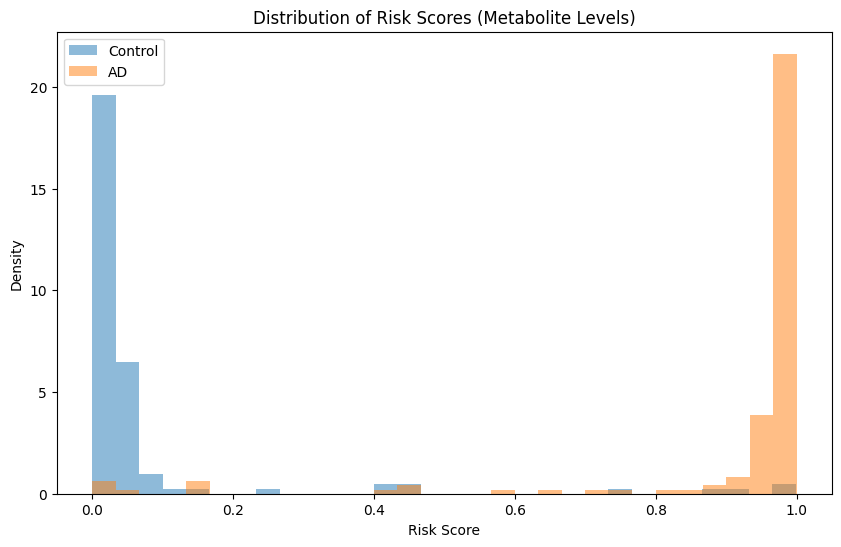

In [3]:
plot_risk_distribution(risk_scores,y, preprocessor.name)


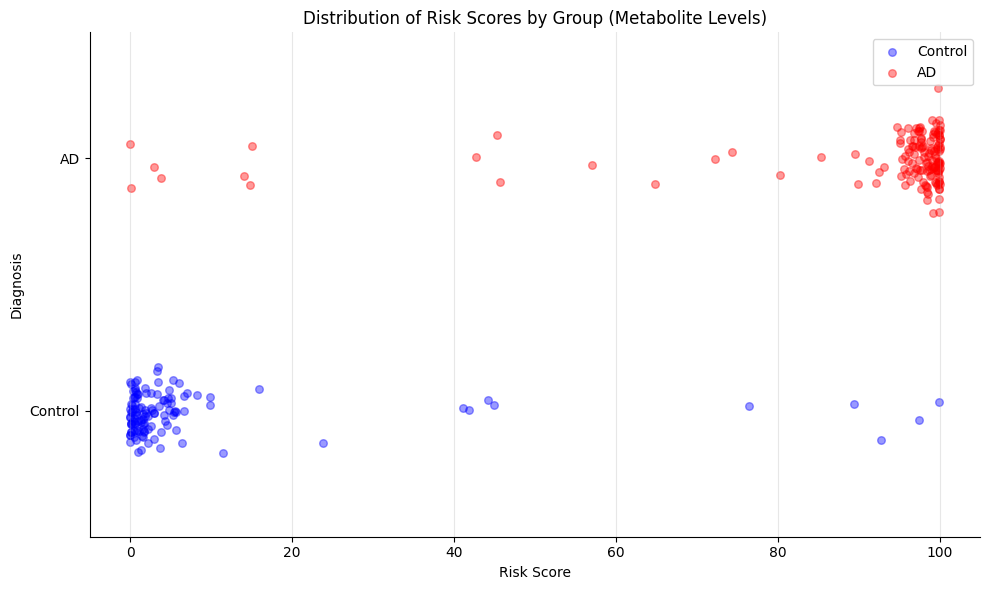

In [4]:
plot_risk_distribution2(risk_scores, y, preprocessor.name)

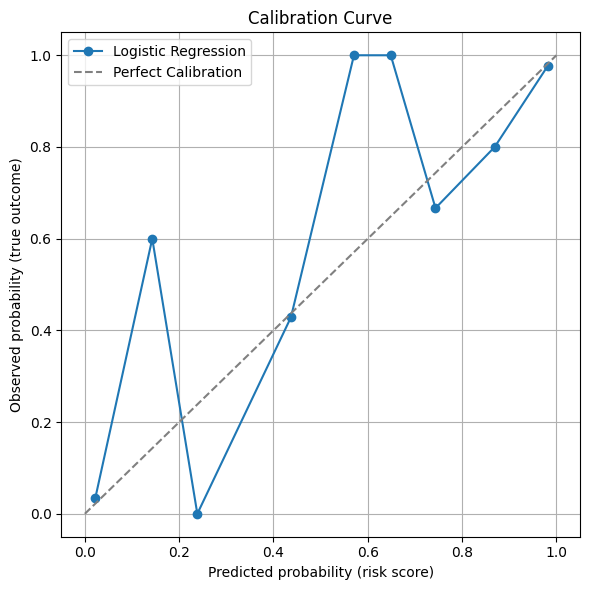

In [5]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Assuming y and risk_scores are already defined
# y: array of true labels (0 or 1)
# risk_scores: predicted probabilities for class 1 (Alzheimer)

# Compute calibration curve
prob_true, prob_pred = calibration_curve(y, risk_scores, n_bins=10, strategy='uniform')

# Plot
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Predicted probability (risk score)')
plt.ylabel('Observed probability (true outcome)')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


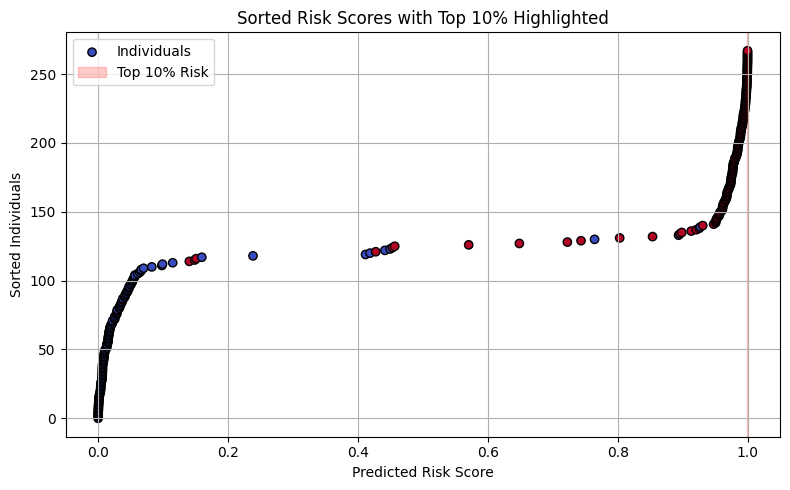

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays
risk_scores = np.array(risk_scores)
y = np.array(y)

# Sort by risk score
sorted_indices = np.argsort(risk_scores)
risk_scores_sorted = risk_scores[sorted_indices]
y_sorted = y[sorted_indices]

# Define threshold for top 10% risk scores
threshold = np.percentile(risk_scores_sorted, 90)

# Create sorted scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(risk_scores_sorted, range(len(risk_scores_sorted)), c=y_sorted, cmap='coolwarm', edgecolor='k', label='Individuals')

# Highlight top 10% region
plt.axvspan(threshold, 1.0, color='red', alpha=0.2, label='Top 10% Risk')

# Formatting
plt.xlabel('Predicted Risk Score')
plt.ylabel('Sorted Individuals')
plt.title('Sorted Risk Scores with Top 10% Highlighted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from analysis.cox_regression import compute_hazard_ratios

from analysis.metabolite_level_analysis import (
    analyse_with_logistic_regression,
    calculate_odds_ratio,
    calculate_hazard_ratio,
    prepare_duration,
    create_ages_df,
    create_ages_df_with_df
)

from preprocessing import (
    MetaboliteLevelsPreprocessorFactory,
    PathwayPreprocessorFactory,
    ReactionPreprocessorFactory,
    MetabolitePathwayCombinedPreprocessorFactory,
    MetaboliteReactionCombinedPreprocessorFactory,
    TranscriptomicsPreprocessorFactory,
    TranscriptomicsMetabolitePreprocessorFactory,
    TranscriptomicsPathwayPreprocessorFactory,
    TranscriptomicsReactionPreprocessorFactory
)
from sklearn.preprocessing import StandardScaler

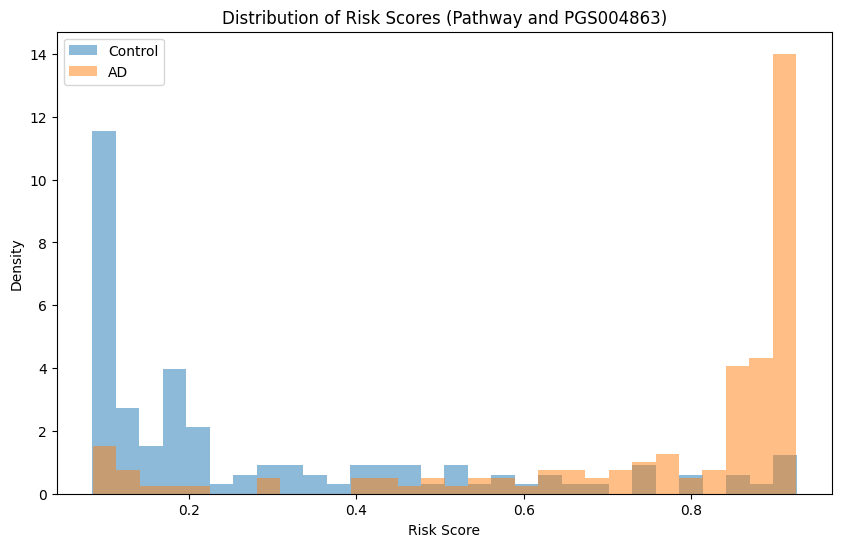

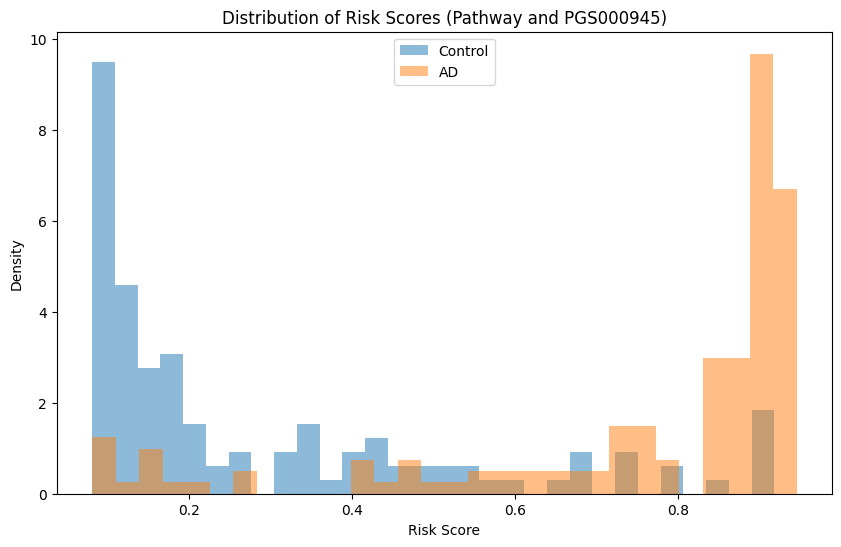

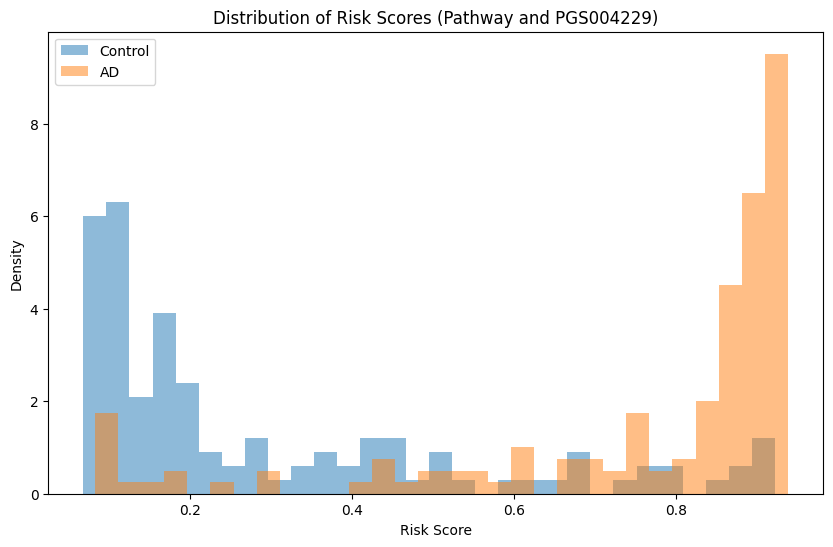

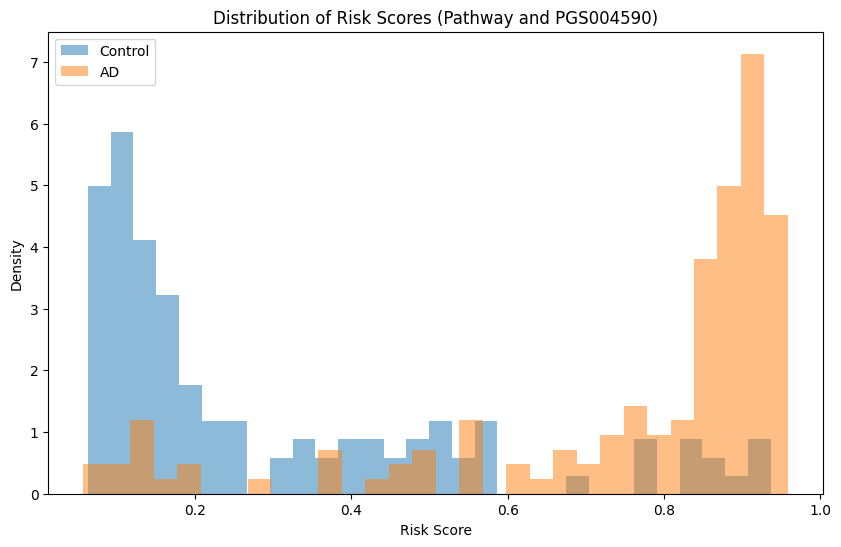

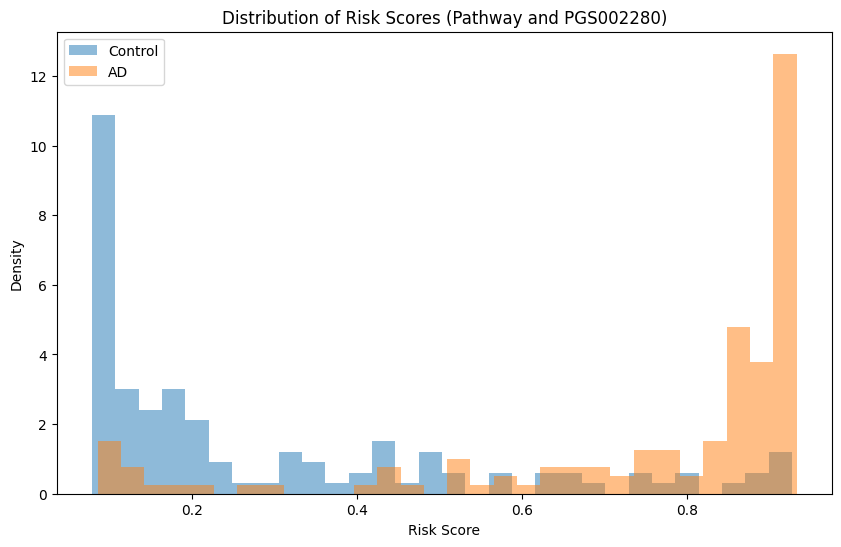

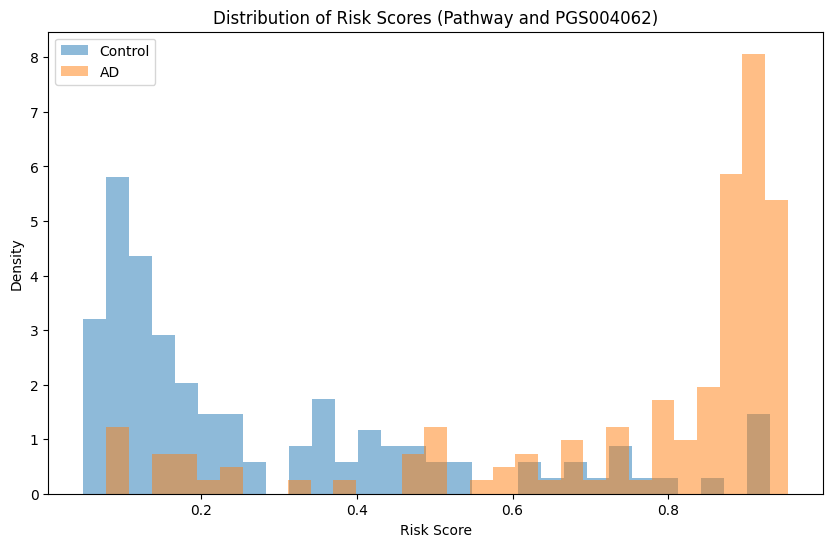

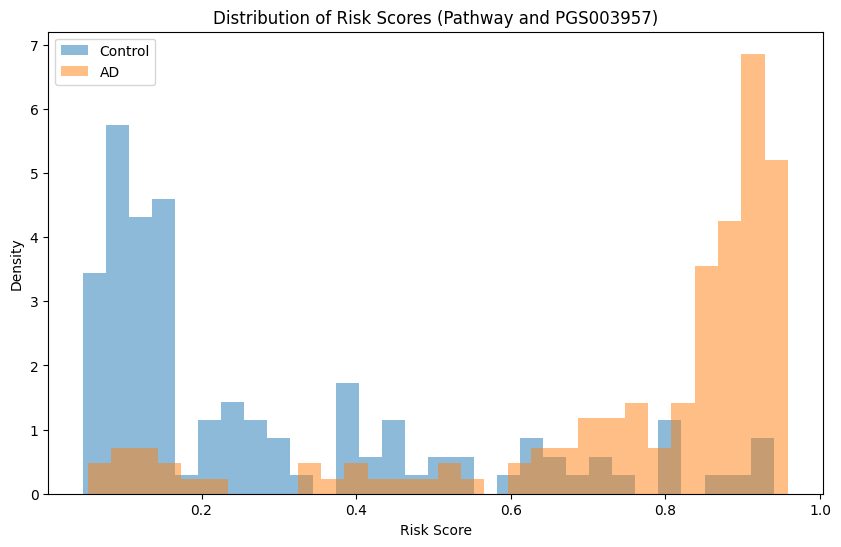

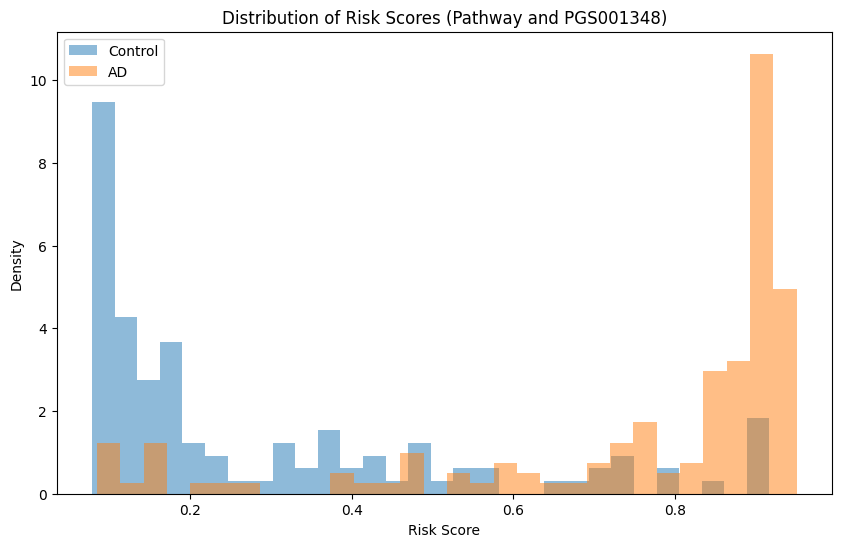

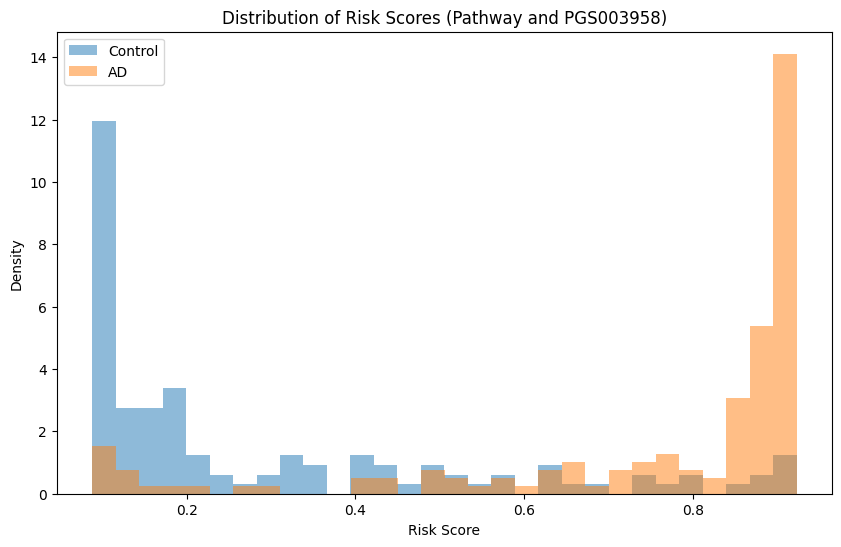

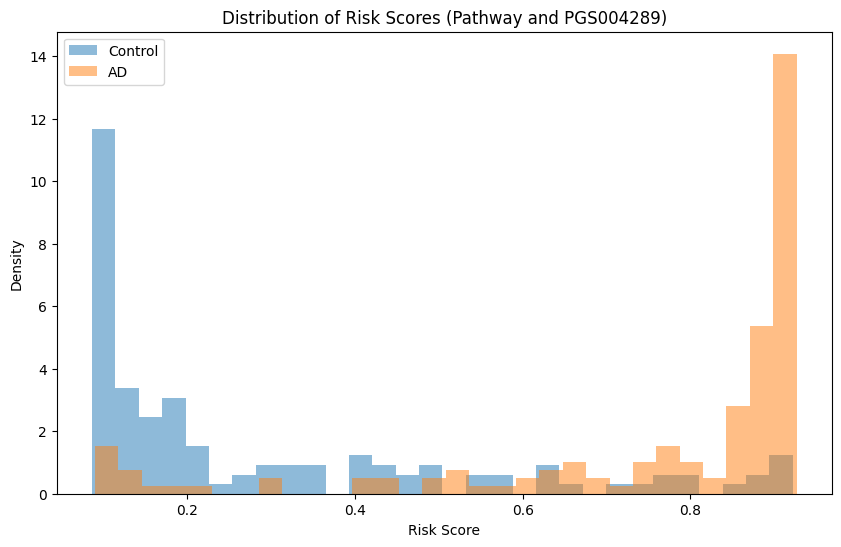

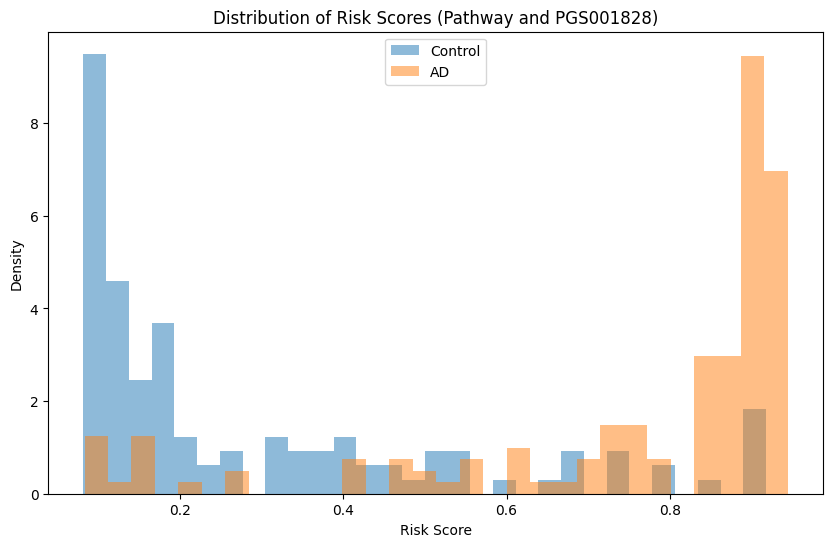

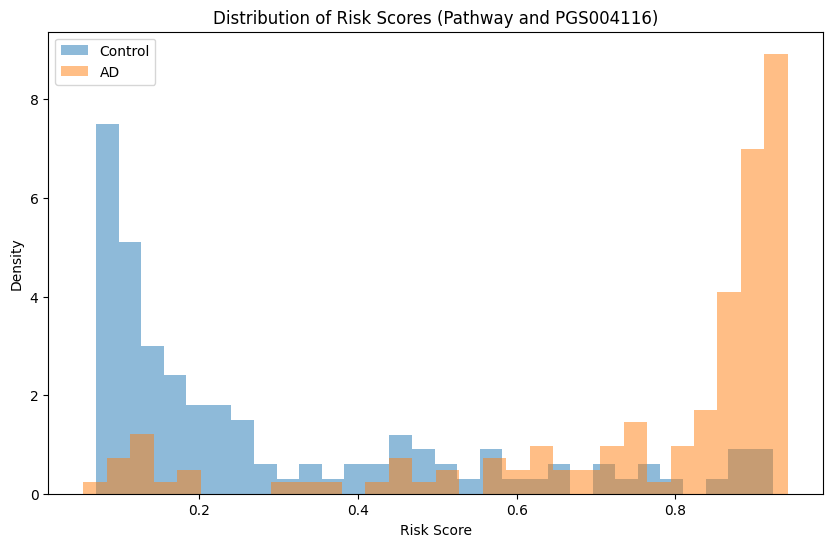

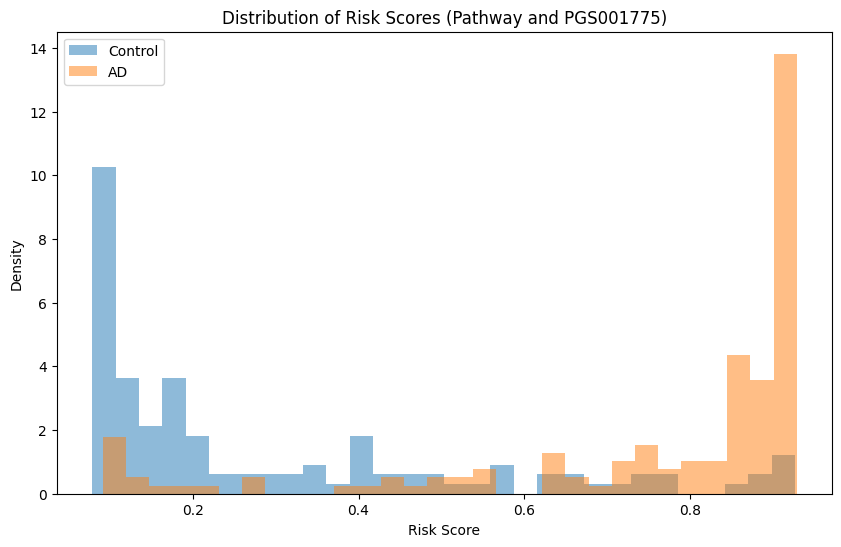

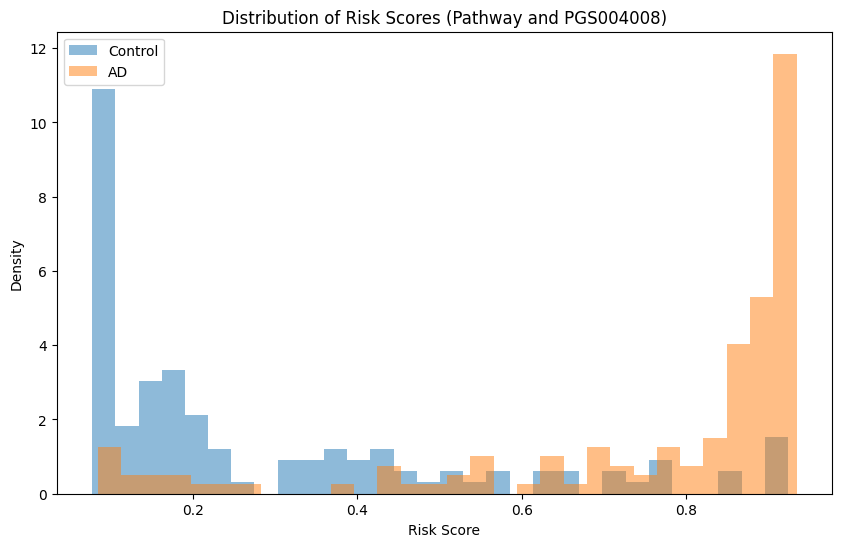

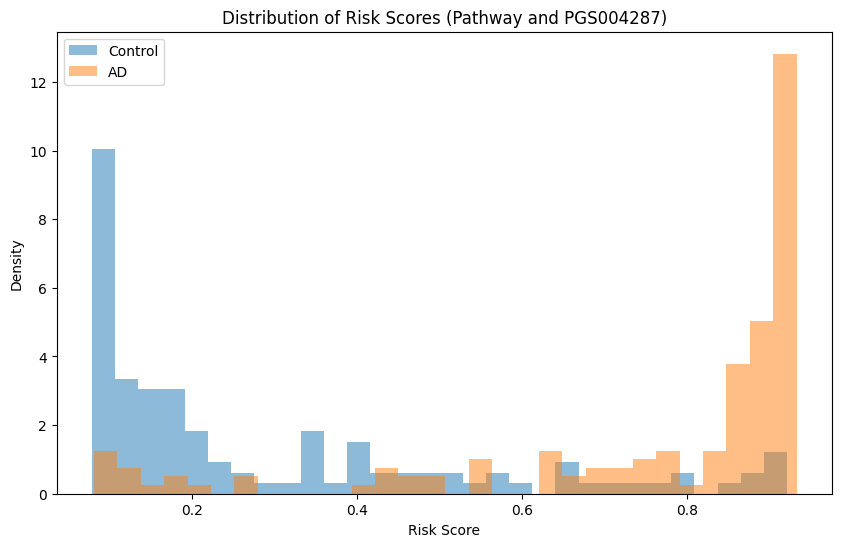

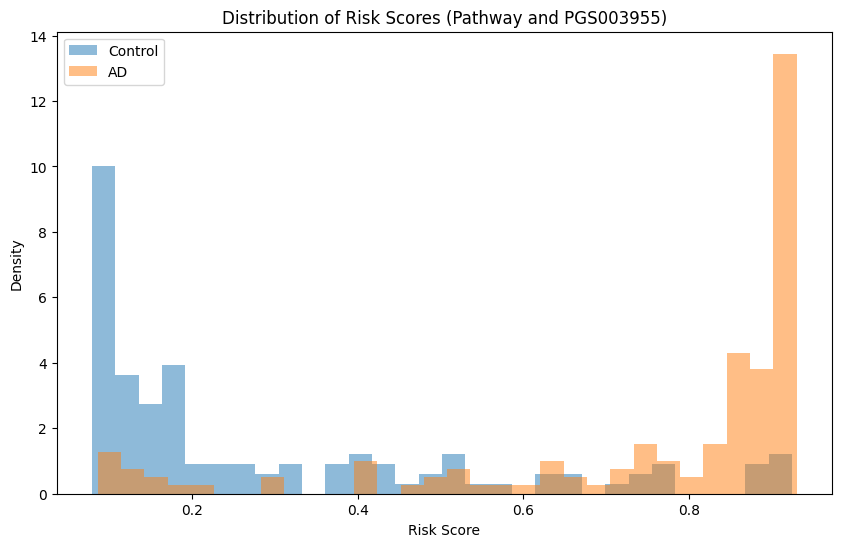

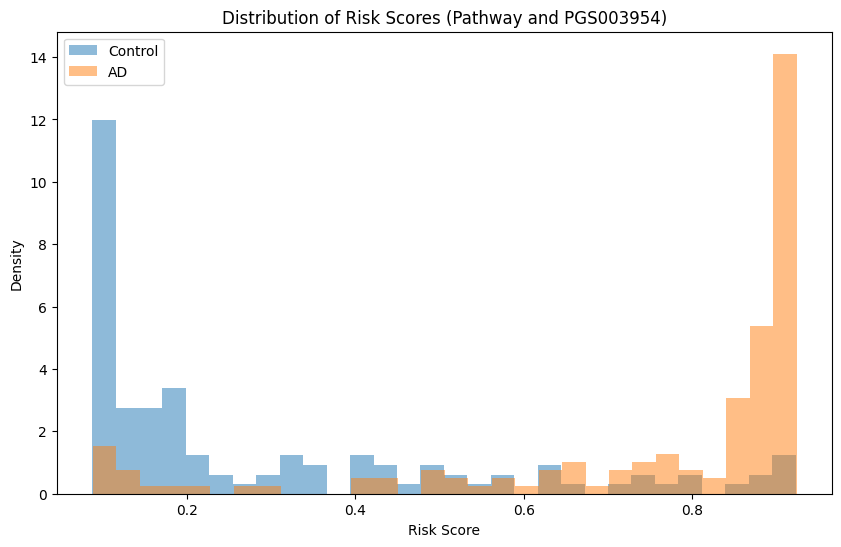

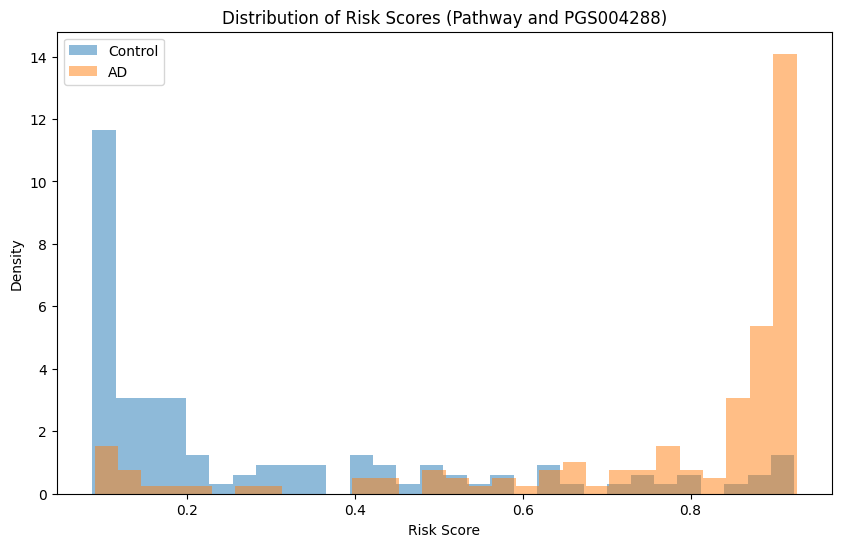

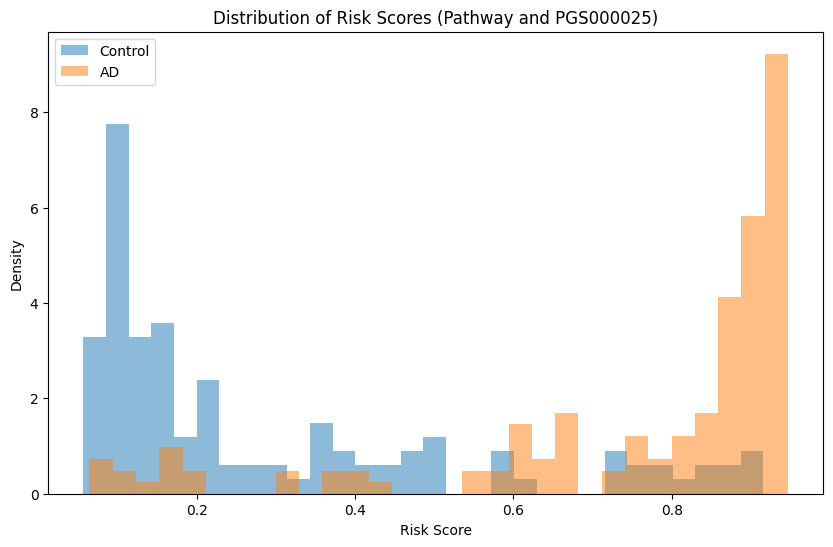

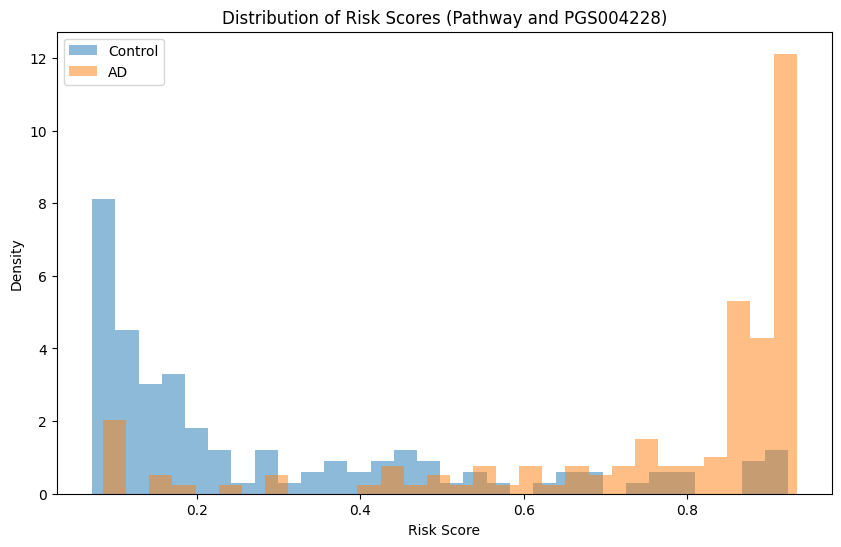

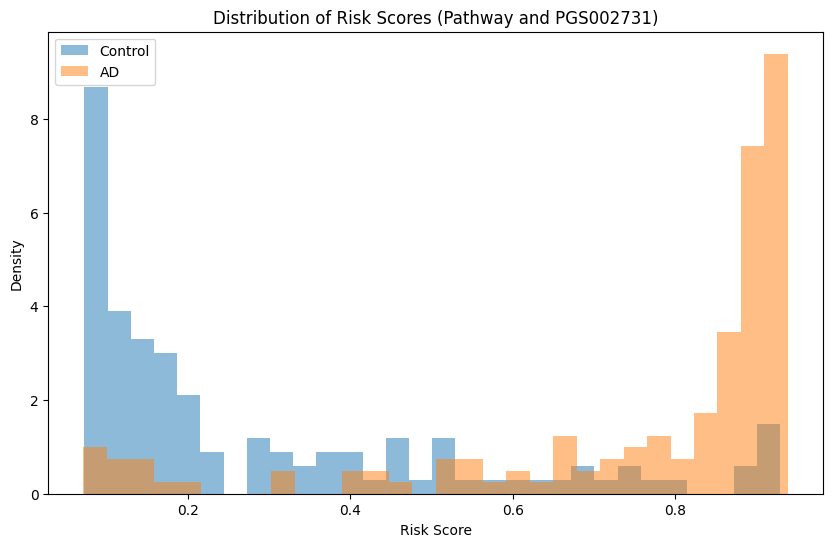

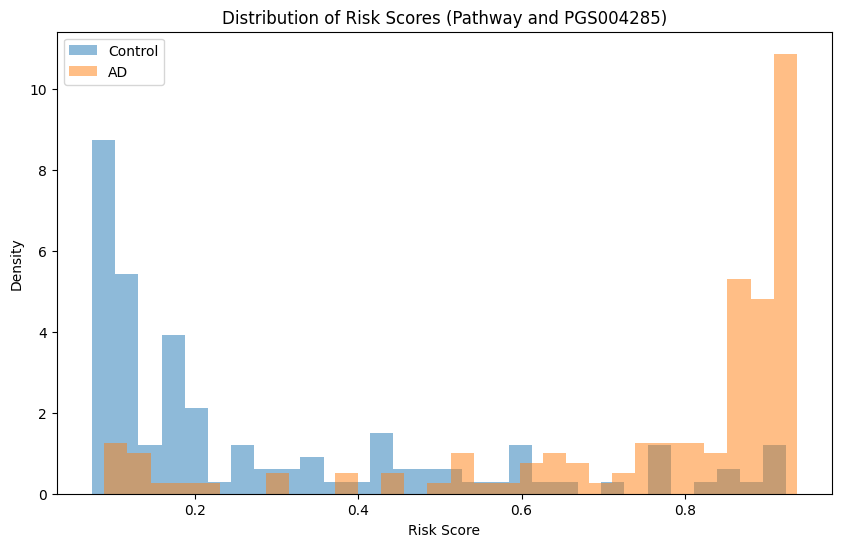

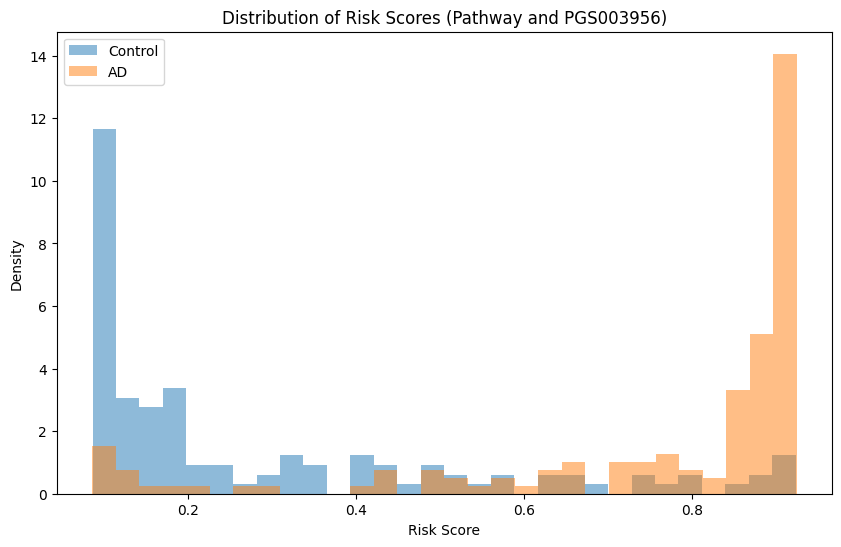

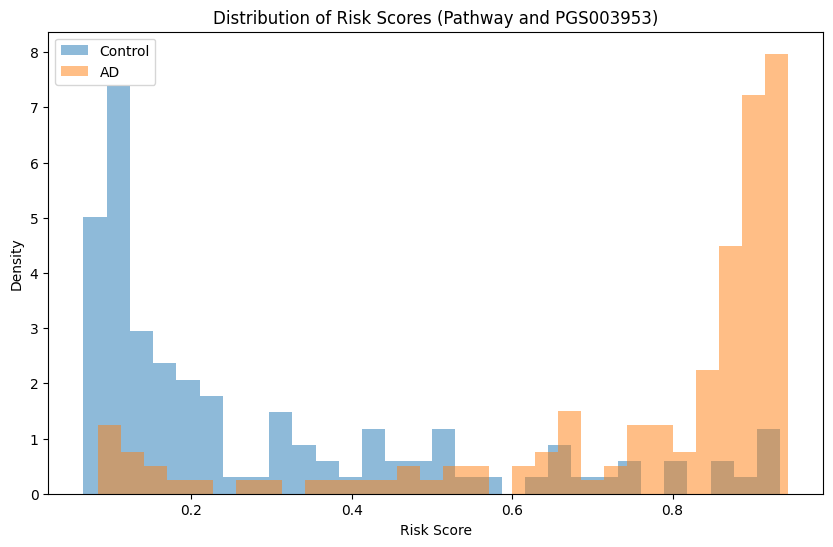

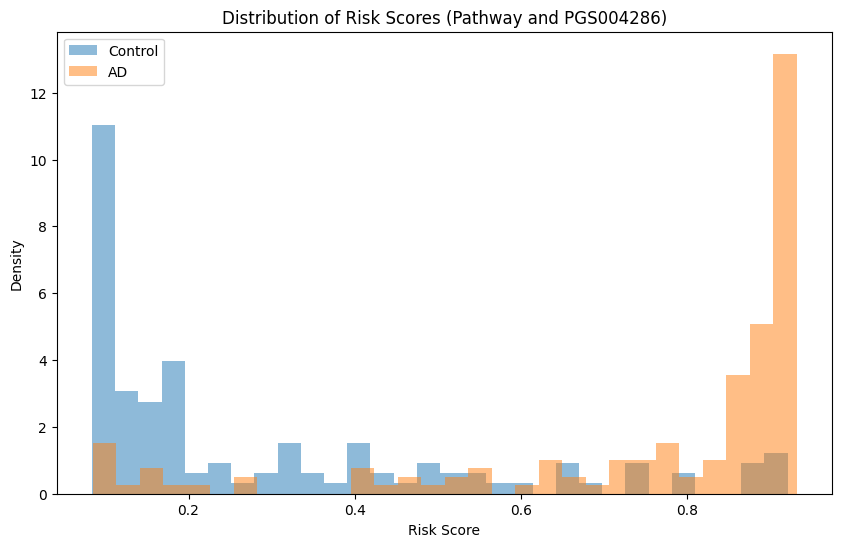

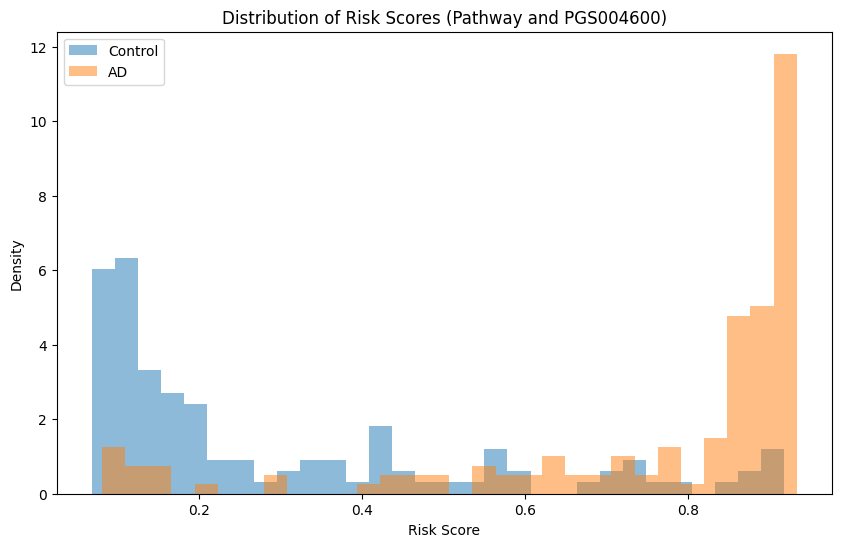

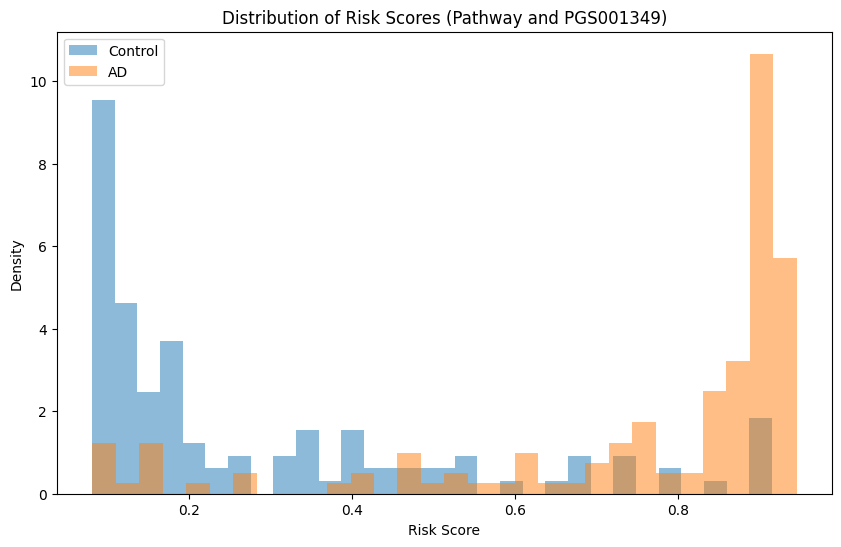

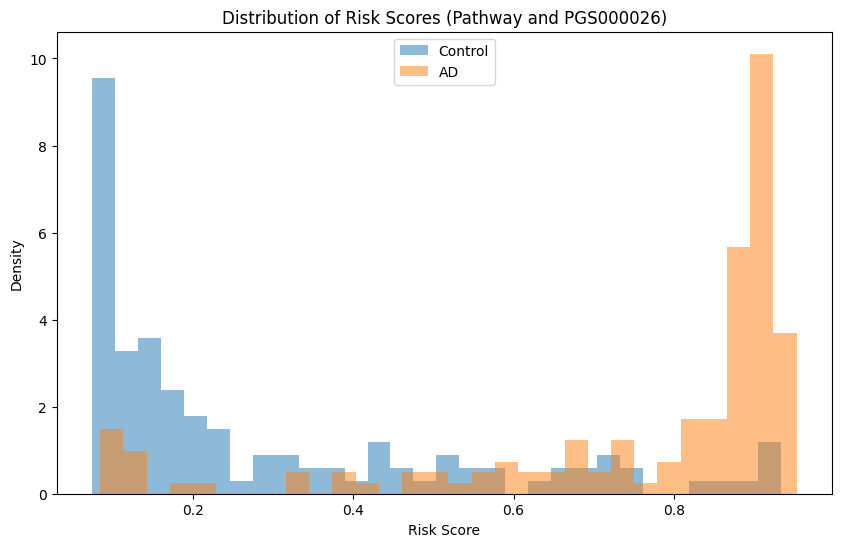

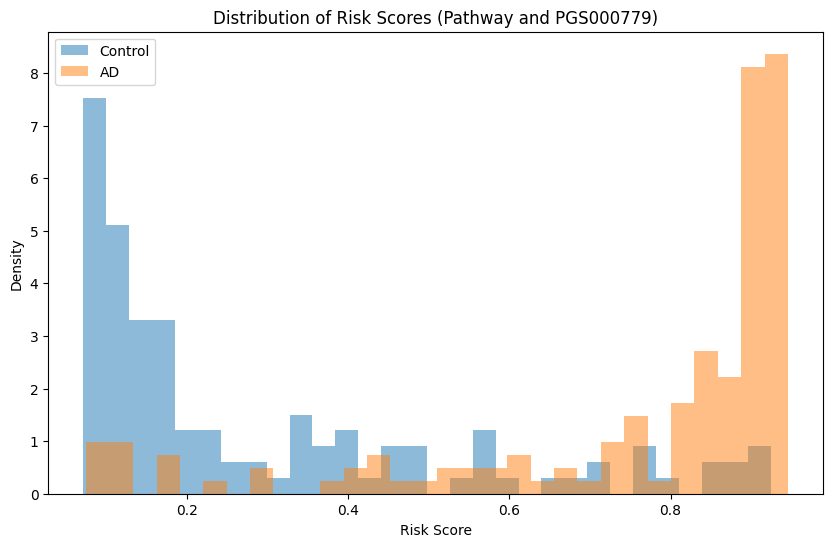

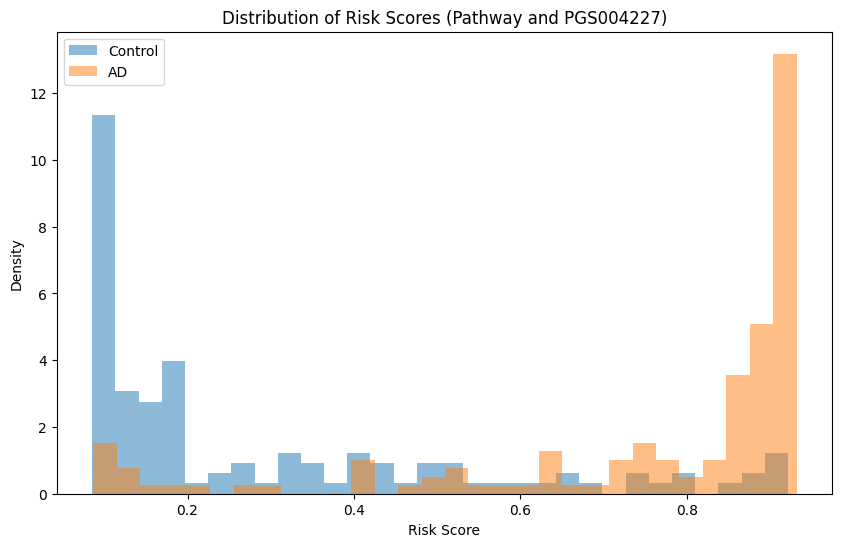

In [8]:
from pathlib import Path
import os
from analysis import calculate_risk_score_with_prs
import glob

risk_scores = {}
prs_combined = paths.prs_combined_path
pathway_file_path = paths.pathway_file_path
reaction_file_path = paths.reaction_file_path
metabolite_level_pathway_combined_file_path = paths.metabolite_level_pathway_combined_file_path
metabolite_level_reaction_combined_file_path = paths.metabolite_level_reaction_combined_file_path
x_pathway_path = paths.x_pathway_path
x_reaction_path = paths.x_reaction_path
# Path to the main folder
main_folder = 'ROSMAP-AD/Final_Prs_Scores'
factory_list = [
    MetaboliteLevelsPreprocessorFactory(metabolite_levels_file_path),
    PathwayPreprocessorFactory(metabolite_levels_file_path, pathway_file_path, x_pathway_path),
    ReactionPreprocessorFactory(metabolite_levels_file_path, reaction_file_path, x_reaction_path),
    MetabolitePathwayCombinedPreprocessorFactory(metabolite_levels_file_path, metabolite_level_pathway_combined_file_path, x_pathway_path),
    MetaboliteReactionCombinedPreprocessorFactory(metabolite_levels_file_path, metabolite_level_reaction_combined_file_path, x_reaction_path)
]
# Loop through each subfolder
for subfolder in os.listdir(main_folder):
    subfolder_path = os.path.join(main_folder, subfolder)

    # Check if it's a directory
    if os.path.isdir(subfolder_path):
        prs_id = subfolder
        csv_path = os.path.join(subfolder_path, 'prs_scores.csv')
        prs_scores = pd.read_csv(csv_path)               # Contains individual IDs and scores
        rosmap_clinical = pd.read_csv('ROSMAP-AD/raw/clinical.csv')     # Contains ID, Study, and projid

        # Merge on individual ID
        rosmap_clinical['sample_id'] = rosmap_clinical['Study'].astype(str) + rosmap_clinical['projid'].astype(str)
        merged = prs_scores.merge(rosmap_clinical, on='sample_id', how='inner')
        prs_df = merged[['sample_id', 'score', 'individualID']]
        factory = PathwayPreprocessorFactory(metabolite_levels_file_path, pathway_file_path, x_pathway_path)
        preprocessor = factory.create_preprocessor()
        y, risk_scores, sample_ids_ = analyse_with_logistic_regression(preprocessor)

        combined_risk_df = calculate_risk_score_with_prs(y, risk_scores, sample_ids_, prs_df, prs_combined)
        plot_risk_distribution(combined_risk_df['combined_score'].to_numpy(), combined_risk_df['Diagnosis'].to_numpy(), 'Pathway and ' +subfolder)